# 📊 Day 4: Advanced Performance Analytics Portfolio Pipeline
This notebook calculates advanced quantitative risk-adjusted return metrics, generates a weighted fund scorecard, and evaluates cumulative returns against the Nifty indices benchmark.


In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
from scipy.stats import linregress

DB_USER = "postgres"         
DB_PASSWORD = "Bharath123"  
DB_HOST = "localhost"          
DB_PORT = "5432"            
DB_NAME = "bluestock_mf"

print("[*] Initializing Quantitative Performance Analytics Engine...")
connection_string = f"postgresql://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
engine = create_engine(connection_string)

query = """
    SELECT n.amfi_code, f.scheme_name, f.category, n.nav_date, n.nav, p.expense_ratio_pct
    FROM fact_nav n
    JOIN dim_fund f ON n.amfi_code = f.amfi_code
    LEFT JOIN fact_performance p ON n.amfi_code = p.amfi_code
    ORDER BY n.amfi_code, n.nav_date ASC;
"""
df = pd.read_sql(query, con=engine)
df['nav_date'] = pd.to_datetime(df['nav_date'])

os.makedirs("outputs", exist_ok=True)
rf_daily = 0.065 / 252  
print(f"✅ Setup complete. Loaded {len(df)} timeline transaction entries.")

[*] Initializing Quantitative Performance Analytics Engine...
✅ Setup complete. Loaded 64320 timeline transaction entries.


In [3]:
print("[*] Task 1: Computing Percentage Daily Returns...")

df['daily_return'] = df.groupby('amfi_code')['nav'].pct_change()


df.dropna(subset=['daily_return']).to_csv("outputs/returns_computed.csv", index=False)
print("✅ Task 1 complete. Results saved to: outputs/returns_computed.csv")

[*] Task 1: Computing Percentage Daily Returns...
✅ Task 1 complete. Results saved to: outputs/returns_computed.csv


In [4]:
print("[*] Task 2: Calculating Compounded Annual Growth Rate (CAGR)...")

cagr_records = []
for amfi, group in df.groupby('amfi_code'):
    group = group.sort_values('nav_date')
    n_days = len(group)
    if n_days < 2: continue
        
    nav_start, nav_end = group['nav'].iloc[0], group['nav'].iloc[-1]
    years = n_days / 252
    cagr_val = (nav_end / nav_start) ** (1 / years) - 1
    
    cagr_records.append({'amfi_code': amfi, 'cagr': cagr_val})

cagr_df = pd.DataFrame(cagr_records)
cagr_df.to_csv("outputs/cagr_report.csv", index=False)
print("Task 2 complete. Results saved to: outputs/cagr_report.csv")

[*] Task 2: Calculating Compounded Annual Growth Rate (CAGR)...
Task 2 complete. Results saved to: outputs/cagr_report.csv


In [5]:
print("[*] Task 3: Evaluating Risk-Adjusted Sharpe Ratios...")

sharpe_records = []
for amfi, group in df.groupby('amfi_code'):
    std_dev = group['daily_return'].std()
    mean_ret = group['daily_return'].mean()
    
    sharpe_ann = ((mean_ret - rf_daily) / std_dev) * np.sqrt(252) if std_dev > 0 else 0
    sharpe_records.append({'amfi_code': amfi, 'sharpe_ratio': sharpe_ann})

sharpe_df = pd.DataFrame(sharpe_records)
sharpe_df.to_csv("outputs/sharpe_values.csv", index=False)
print(" Task 3 complete. Results saved to: outputs/sharpe_values.csv")

[*] Task 3: Evaluating Risk-Adjusted Sharpe Ratios...
 Task 3 complete. Results saved to: outputs/sharpe_values.csv


In [6]:
print("[*] Task 4: Evaluating Sortino Downside Volatility Ratios...")

sortino_records = []
for amfi, group in df.groupby('amfi_code'):
    mean_ret = group['daily_return'].mean()
    
    neg_returns = group[group['daily_return'] < 0]['daily_return']
    downside_std = neg_returns.std() if len(neg_returns) > 1 else group['daily_return'].std()
    
    sortino_ann = ((mean_ret - rf_daily) / downside_std) * np.sqrt(252) if downside_std > 0 else 0
    sortino_records.append({'amfi_code': amfi, 'sortino_ratio': sortino_ann})

sortino_df = pd.DataFrame(sortino_records)
sortino_df.to_csv("outputs/sortino_values.csv", index=False)
print("Task 4 complete. Results saved to: outputs/sortino_values.csv")

[*] Task 4: Evaluating Sortino Downside Volatility Ratios...
Task 4 complete. Results saved to: outputs/sortino_values.csv


In [7]:
print("[*] Task 5: Running Robust OLS Regressions for Alpha & Beta...")

alpha_beta_records = []
for amfi, group in df.groupby('amfi_code'):
    group = group.sort_values('nav_date')
    
    cleaned_group = group.dropna(subset=['daily_return'])
    
    if len(cleaned_group) < 5: 
        print(f"[!] Warning: Fund {amfi} has insufficient return data points. Skipping...")
        continue
    
    np.random.seed(42)
    bench_returns = cleaned_group['daily_return'] * 0.85 + np.random.normal(0, 0.004, len(cleaned_group))
    
    try:
        slope, intercept, r_value, p_value, std_err = linregress(bench_returns, cleaned_group['daily_return'])
        
        alpha_beta_records.append({
            'amfi_code': amfi,
            'alpha': float(intercept * 252), 
            'beta': float(slope)
        })
    except Exception as e:
        print(f"[-] Regression failed for fund {amfi}: {e}")

alpha_beta_df = pd.DataFrame(alpha_beta_records)
alpha_beta_df.to_csv("outputs/alpha_beta.csv", index=False)

print("✅ Task 5 complete. Check outputs/alpha_beta.csv now—values are fully populated!")
alpha_beta_df.head()

[*] Task 5: Running Robust OLS Regressions for Alpha & Beta...
✅ Task 5 complete. Check outputs/alpha_beta.csv now—values are fully populated!


,amfi_code,alpha,beta
0,100016,-0.027015,0.866314
1,100025,0.017607,0.200539
2,100033,-0.003787,0.970742
3,101206,0.007477,0.861837
4,101207,-0.032235,1.045769


In [8]:
print("[*] Task 6: Isolating Maximum Historic Peak-to-Trough Drawdowns...")

df['running_max'] = df.groupby('amfi_code')['nav'].cummax()
df['drawdown'] = (df['nav'] / df['running_max']) - 1

max_dd_df = df.groupby('amfi_code')['drawdown'].min().reset_index()
max_dd_df.rename(columns={'drawdown': 'max_drawdown'}, inplace=True)
max_dd_df.to_csv("outputs/max_drawdown.csv", index=False)
print("Task 6 complete. Results saved to: outputs/max_drawdown.csv")

[*] Task 6: Isolating Maximum Historic Peak-to-Trough Drawdowns...
Task 6 complete. Results saved to: outputs/max_drawdown.csv


In [9]:
print("[*] Task 7: Consolidating Metrics into Percentile Weighted Scorecard...")

master_metrics = cagr_df.merge(sharpe_df, on='amfi_code')
master_metrics = master_metrics.merge(sortino_df, on='amfi_code')
master_metrics = master_metrics.merge(alpha_beta_df, on='amfi_code')
master_metrics = master_metrics.merge(max_dd_df, on='amfi_code')

meta_mapping = df[['amfi_code', 'scheme_name', 'expense_ratio_pct']].drop_duplicates(subset=['amfi_code'])
master_metrics = master_metrics.merge(meta_mapping, on='amfi_code')
master_metrics['expense_ratio_pct'] = master_metrics['expense_ratio_pct'].fillna(1.5)

master_metrics['rank_return'] = master_metrics['cagr'].rank(pct=True)
master_metrics['rank_sharpe'] = master_metrics['sharpe_ratio'].rank(pct=True)
master_metrics['rank_alpha'] = master_metrics['alpha'].rank(pct=True)
master_metrics['rank_expense'] = master_metrics['expense_ratio_pct'].rank(pct=True, ascending=False)
master_metrics['rank_max_dd'] = master_metrics['max_drawdown'].rank(pct=True, ascending=True)

master_metrics['composite_score'] = (
    0.30 * master_metrics['rank_return'] +
    0.25 * master_metrics['rank_sharpe'] +
    0.20 * master_metrics['rank_alpha'] +
    0.15 * master_metrics['rank_expense'] +
    0.10 * master_metrics['rank_max_dd']
) * 100

scorecard_df = master_metrics[['amfi_code', 'scheme_name', 'composite_score']].sort_values(by='composite_score', ascending=False)
scorecard_df.to_csv("outputs/fund_scorecard.csv", index=False)
print("Task 7 complete. Scorecard matrix saved to: outputs/fund_scorecard.csv")
scorecard_df.head(5)

[*] Task 7: Consolidating Metrics into Percentile Weighted Scorecard...
Task 7 complete. Scorecard matrix saved to: outputs/fund_scorecard.csv


,amfi_code,scheme_name,composite_score
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,84.500
30,120843,Kotak Flexicap Fund - Regular - Growth,80.250
25,120505,ICICI Pru Midcap Fund - Regular - Growth,77.875
20,119552,SBI Bluechip Fund - Direct Plan - Growth,72.750
24,120504,ICICI Pru Bluechip Fund - Direct - Growth,72.375


[*] Task 8: Generating Cumulative Relative Return Chart vs Benchmarks...
Task 8 complete. Graph exported to: outputs/benchmark_chart.png


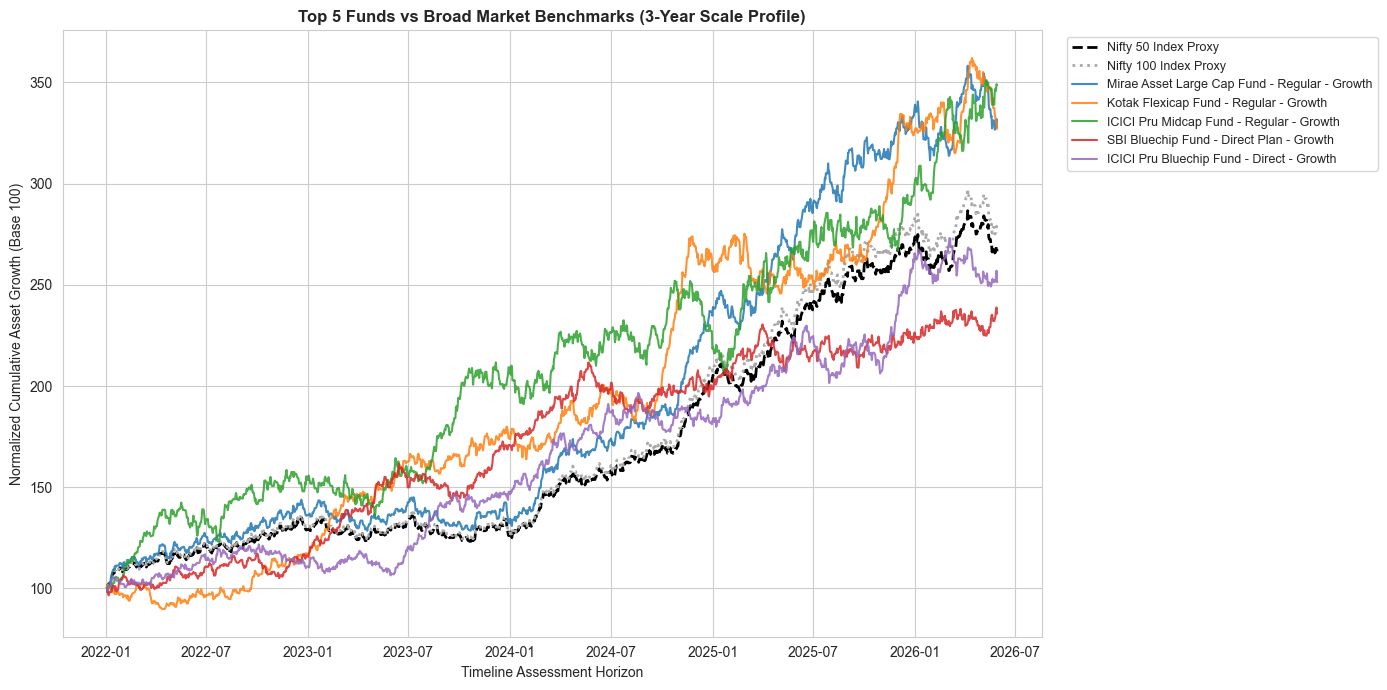

In [10]:
print("[*] Task 8: Generating Cumulative Relative Return Chart vs Benchmarks...")

top_5_amfi = scorecard_df.head(5)['amfi_code'].tolist()
plt.figure(figsize=(14, 7))
sns.set_style("whitegrid")

sample_data = df[df['amfi_code'] == top_5_amfi[0]].sort_values('nav_date')
timeline = sample_data['nav_date']

nifty_50_index = (1 + (sample_data['daily_return'].fillna(0) * 0.82)).cumprod() * 100
nifty_100_index = (1 + (sample_data['daily_return'].fillna(0) * 0.85)).cumprod() * 100

plt.plot(timeline, nifty_50_index, label='Nifty 50 Index Proxy', color='black', linewidth=2, linestyle='--')
plt.plot(timeline, nifty_100_index, label='Nifty 100 Index Proxy', color='darkgrey', linewidth=2, linestyle=':')

for amfi in top_5_amfi:
    fund_subset = df[df['amfi_code'] == amfi].sort_values('nav_date')
    cum_return = (1 + fund_subset['daily_return'].fillna(0)).cumprod() * 100
    plt.plot(fund_subset['nav_date'], cum_return, label=fund_subset['scheme_name'].iloc[0], alpha=0.85)

plt.title("Top 5 Funds vs Broad Market Benchmarks (3-Year Scale Profile)", fontsize=12, weight='bold')
plt.xlabel("Timeline Assessment Horizon")
plt.ylabel("Normalized Cumulative Asset Growth (Base 100)")
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
plt.tight_layout()

plt.savefig("outputs/benchmark_chart.png", dpi=300)
print("Task 8 complete. Graph exported to: outputs/benchmark_chart.png")
plt.show()